In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)

In [ ]:
df_prd = pd.read_json(r"../data/raw/products.json")
df_prd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    40 non-null     object
 1   product_name  40 non-null     object
 2   category      40 non-null     object
 3   unit_price    40 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.4+ KB


In [ ]:
df = pd.read_csv(r"../data/processed/processed_orders_data.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       1925 non-null   object
 1   product_id     1925 non-null   object
 2   quantity       1925 non-null   int64 
 3   order_date     1925 non-null   object
 4   customer_city  1925 non-null   object
 5   payment_mode   1925 non-null   object
 6   order_status   1925 non-null   object
dtypes: int64(1), object(6)
memory usage: 105.4+ KB


In [29]:
df = df.merge(df_prd,how='left')
df

,order_id,product_id,quantity,order_date,customer_city,payment_mode,order_status,product_name,category,unit_price
0,ORD2263,P009,1,2025-10-02,Delhi,Cash On Delivery,Delivered,Amul Cheese Slices 200g,Dairy,135.0
1,ORD1298,P003,10,2024-12-25,Pune,Cash On Delivery,Delivered,Fortune Sunflower Oil 1L,Staples,135.0
2,ORD1060,P002,8,2025-02-05,Pune,Net Banking,Cancelled,Aashirvaad Atta 5kg,Staples,275.0
3,ORD2697,P002,9,2024-12-13,Ahmedabad,Cash On Delivery,Delivered,Aashirvaad Atta 5kg,Staples,275.0
4,ORD1744,P008,2,2024-12-07,Mumbai,Net Banking,Delivered,Mother Dairy Curd 400g,Dairy,48.0
5,ORD2544,P033,3,2025-05-01,Ahmedabad,Cash On Delivery,Delivered,Colgate Strong Teeth 300g,Personal Care,129.0
6,ORD1977,P002,1,2024-12-13,Delhi,UPI,Delivered,Aashirvaad Atta 5kg,Staples,275.0
7,ORD1353,P034,7,2025-01-29,Mumbai,Debit Card,Delivered,Dettol Handwash 250ml,Personal Care,89.0
8,ORD2432,P033,2,2025-01-22,Delhi,Net Banking,Delivered,Colgate Strong Teeth 300g,Personal Care,129.0
9,ORD2402,P007,1,2024-12-18,Bangalore,Net Banking,Cancelled,Amul Butter 500g,Dairy,285.0


## 1) What is the total revenue generated across all orders this period?

In [33]:
df['total_amount'] = df['quantity']*df['unit_price']
df.apply()
df['total_amount'] = df.apply(
    lambda x: x['total_amount'] if x['order_status'] == "Delivered" else None,
    axis=1
)
total_revenue = df['total_amount'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")
df[:10]

Total Revenue: 5,831,509.00


,order_id,product_id,quantity,order_date,customer_city,payment_mode,order_status,product_name,category,unit_price,total_amount
0,ORD2263,P009,1,2025-10-02,Delhi,Cash On Delivery,Delivered,Amul Cheese Slices 200g,Dairy,135.0,135.0
1,ORD1298,P003,10,2024-12-25,Pune,Cash On Delivery,Delivered,Fortune Sunflower Oil 1L,Staples,135.0,1350.0
2,ORD1060,P002,8,2025-02-05,Pune,Net Banking,Cancelled,Aashirvaad Atta 5kg,Staples,275.0,NaN
3,ORD2697,P002,9,2024-12-13,Ahmedabad,Cash On Delivery,Delivered,Aashirvaad Atta 5kg,Staples,275.0,2475.0
4,ORD1744,P008,2,2024-12-07,Mumbai,Net Banking,Delivered,Mother Dairy Curd 400g,Dairy,48.0,96.0
5,ORD2544,P033,3,2025-05-01,Ahmedabad,Cash On Delivery,Delivered,Colgate Strong Teeth 300g,Personal Care,129.0,387.0
6,ORD1977,P002,1,2024-12-13,Delhi,UPI,Delivered,Aashirvaad Atta 5kg,Staples,275.0,275.0
7,ORD1353,P034,7,2025-01-29,Mumbai,Debit Card,Delivered,Dettol Handwash 250ml,Personal Care,89.0,623.0
8,ORD2432,P033,2,2025-01-22,Delhi,Net Banking,Delivered,Colgate Strong Teeth 300g,Personal Care,129.0,258.0
9,ORD2402,P007,1,2024-12-18,Bangalore,Net Banking,Cancelled,Amul Butter 500g,Dairy,285.0,NaN


In [34]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce'
)

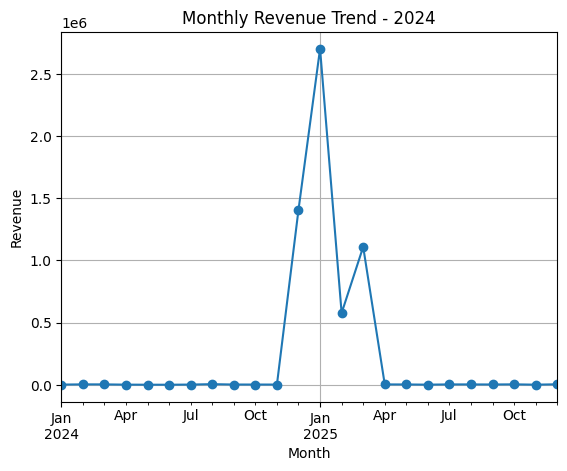

In [35]:
monthly_revenue = (
    df
    .groupby(df['order_date'].dt.to_period('M'))['total_amount']
    .sum()
)

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend - 2024')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

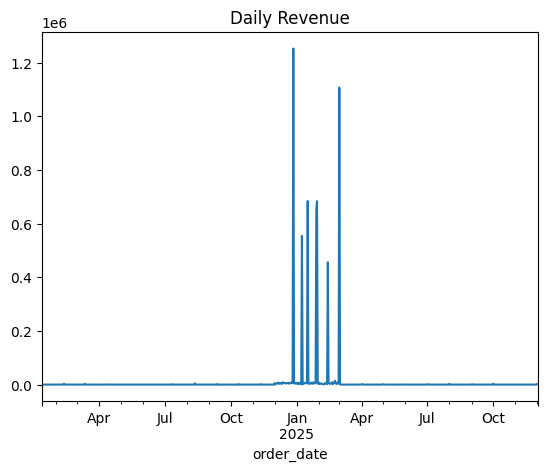

In [36]:
df = df.set_index('order_date')
daily_revenue = df['total_amount'].resample('D').sum()

daily_revenue.plot()
plt.title('Daily Revenue')
plt.show()

## 2) Which product category contributed the highest total revenue?2

In [37]:
df_del = df[df['order_status']=="Delivered"]

In [38]:
category_revenue = (
    df_del.groupby('category')['total_amount'].sum().sort_values(ascending=False)
)

category_revenue

category
Staples          1890031.0
Beverages        1324230.0
Dairy             756683.0
Snacks            682375.0
Personal Care     616127.0
Vegetables        477601.0
Household          56755.0
Ready to Cook      27707.0
Name: total_amount, dtype: float64

In [39]:
top_category = category_revenue.idxmax()
top_revenue = category_revenue.max()

category_percent = (
    category_revenue / category_revenue.sum() * 100
)

print(f"Percentage Contributionn: {category_percent}")
print(f"Top Category: {top_category}")
print(f"Revenue: ₹{top_revenue:,.2f}")

Percentage Contributionn: category
Staples          32.410668
Beverages        22.708188
Dairy            12.975767
Snacks           11.701517
Personal Care    10.565481
Vegetables        8.190007
Household         0.973247
Ready to Cook     0.475126
Name: total_amount, dtype: float64
Top Category: Staples
Revenue: ₹1,890,031.00


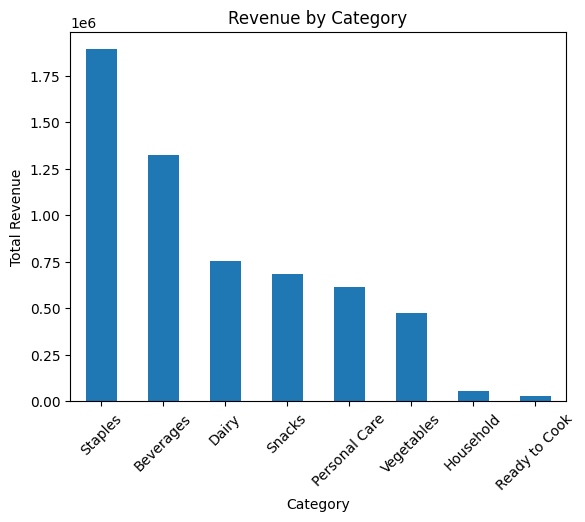

In [40]:
category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 3) Which product was ordered the most by total quantity sold?

In [41]:
df_del.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

product_name
Amul Full Cream Milk 1L    10198
Parle-G Biscuits 800g      10172
Dove Soap 100g             10132
Capsicum 500g              10123
Red Bull 250ml             10117
Toor Dal 500g              10067
India Gate Basmati 1kg     10059
Maggi Noodles 70g            279
Sunfeast Yippee Noodles      249
Aashirvaad Atta 5kg          249
Name: quantity, dtype: int64

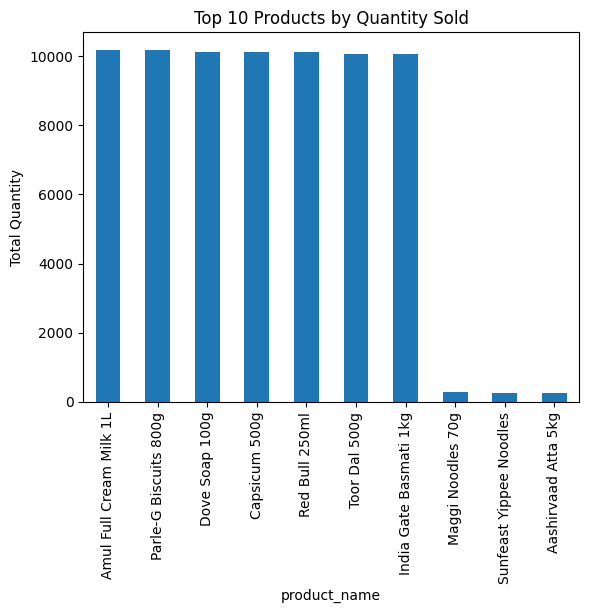

In [42]:
top_products = (df_del.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.ylabel('Total Quantity')
plt.show()

## 4) Which city placed the highest number of orders?

In [43]:
df.groupby('customer_city')['order_id'].count().sort_values(ascending = False)

customer_city
Calcutta     261
Delhi        247
Bangalore    242
Chennai      241
Ahmedabad    237
Hyderabad    235
Mumbai       229
Pune         220
Bombay        13
Name: order_id, dtype: int64

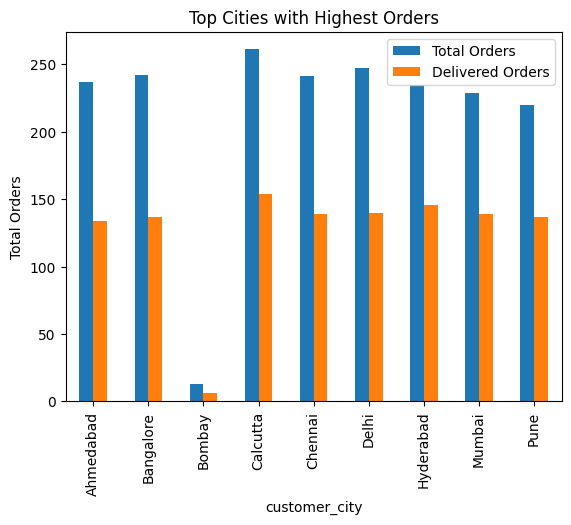

In [50]:
total_orders = (df.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head(10))
delivered_orders = (df_del.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head(10))

summary = pd.DataFrame({
    'Total Orders': total_orders,
    'Delivered Orders': delivered_orders
}).fillna(0)

summary.plot(kind='bar')
plt.title('Top Cities with Highest Orders')
plt.ylabel('Total Orders')
plt.show()

## 5) How many orders had a quantity of zero after null-filling, and what percentage of total orders is that?

In [45]:
total_orders = len(df)
zero_qty_orders = (df['quantity'] == 0).sum()
percentage = (zero_qty_orders / total_orders) * 100
print("Total Orders:", total_orders)
print("Orders with Quantity = 0 is", zero_qty_orders)
print("Percentage of Total Orders: {:.2f}%".format(percentage))

Total Orders: 1925
Orders with Quantity = 0 is 110
Percentage of Total Orders: 5.71%


## 6) What is the average order value (average total_revenue per order)?

In [47]:
total_orders = (df_del['order_id'].count())
total_revenue = (df_del['total_amount'].sum())
print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)

Total Orders: 1132
Total Revenue: 5831509.0


In [48]:
print(f"Average Order Value: {round(total_revenue/total_orders,2)}")

Average Order Value: 5151.51
